In [1]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy
import matplotlib.pyplot as plt
import numpy as np
import dask



In [2]:
u10 = xr.open_zarr("/datasets/zarr_data_uv_1980/10m_u_component_of_wind.zarr")


/usr/local/lib/python3.10/dist-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.24.2
  warnings.warn(


In [5]:
u10['time']

<xarray.DataArray 'time' (time: 72312)> Size: 578kB
array(['1980-01-01T00:00:00.000000000', '1980-01-01T01:00:00.000000000',
       '1980-01-01T02:00:00.000000000', ..., '1988-03-31T21:00:00.000000000',
       '1988-03-31T22:00:00.000000000', '1988-03-31T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 578kB 1980-01-01 ... 1988-03-31T23:00:00

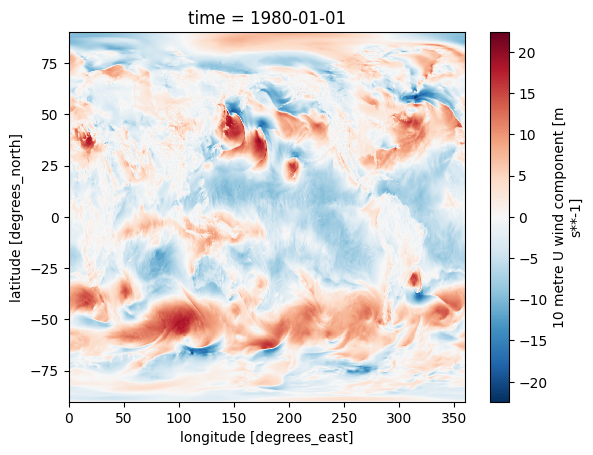

In [6]:
u10['u10'].isel(time=0).plot()

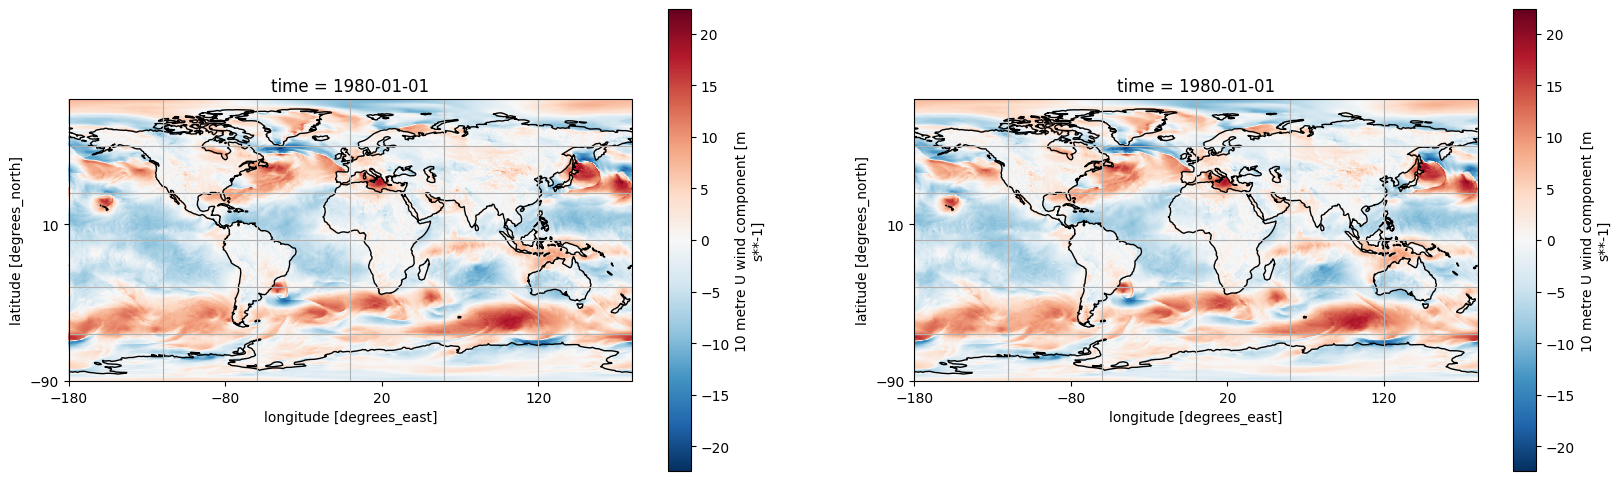

In [9]:
# u10_plot = u10['u10'].sel(time="2015-09-27T04:00:00", method="nearest")
# hs_plot = hs['swh'].sel(time="2015-09-27T04:00:00", method="nearest")

u10_plot = u10['u10'].isel(time=0)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})

ax1.coastlines(resolution="110m")
# 添加经纬度坐标
ax1.set_xticks(range(-180, 181, 100), crs=ccrs.PlateCarree())
ax1.set_yticks(range(-90, 91, 100), crs=ccrs.PlateCarree())
ax1.gridlines(draw_labels=False)
plot1 = u10_plot.plot(ax=ax1, transform=ccrs.PlateCarree(),cbar_kwargs={"shrink": 0.6})

# # 设置显示范围（放大显示某个区域）
# min_lon, max_lon = 120, 130  # 替换为你想要的经度范围
# min_lat, max_lat = 20, 30   # 替换为你想要的纬度范围
# ax2.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

ax2.coastlines(resolution="110m")
# 添加经纬度坐标
ax2.set_xticks(range(-180, 181, 100), crs=ccrs.PlateCarree())
ax2.set_yticks(range(-90, 91, 100), crs=ccrs.PlateCarree())
ax2.gridlines(draw_labels=False)
plot2 = u10_plot.plot(ax=ax2, transform=ccrs.PlateCarree(),cbar_kwargs={"shrink": 0.6})

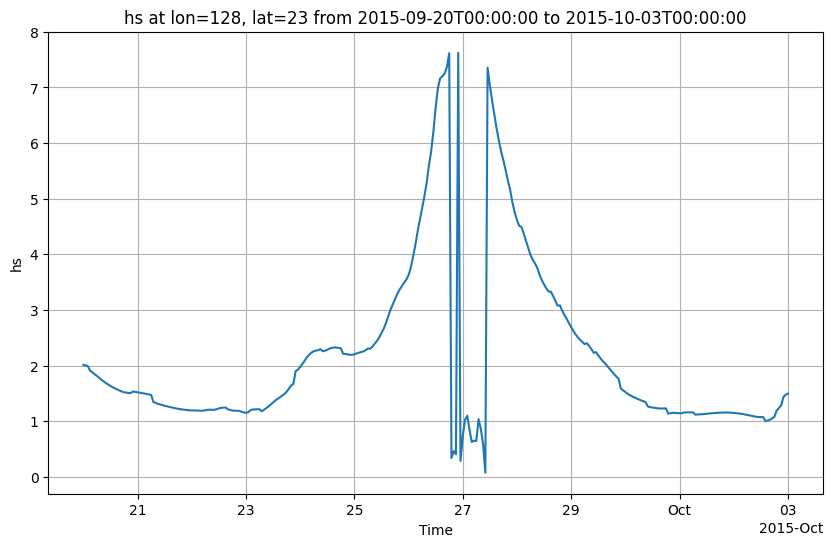

In [23]:

start_time = "2015-09-20T00:00:00"  # 开始时间
end_time = "2015-10-03T00:00:00"    # 结束时间
hs_time_range = hs['swh'].sel(time=slice(start_time, end_time))

# 选择特定经纬度点的数据
lon, lat = 128, 23  # 经纬度
hs_point = hs_time_range.sel(longitude=lon, latitude=lat, method="nearest")

# 绘制时间序列图
plt.figure(figsize=(10, 6))
hs_point.plot()
plt.title(f'hs at lon={lon}, lat={lat} from {start_time} to {end_time}')
plt.xlabel('Time')
plt.ylabel('hs')
plt.grid(True)
plt.show()